  # Uso de redes generativas para la mejora de la señal astronómica



 El presente "notebook" documenta la extracción y emparejamiento de los datos de Gaia y SDSS.



 Puesto que SDSS tiene menos datos con espectrografía que los que proporciona el crossmatch de Gaia, para mostrar los gráficos usaremos un ejemplo aleatorio de SDSS para mostrar la misma espectrometría para ese objeto en Gaia.cÑw



 El procedimiento será el siguiente:

 1. De Gaia, obtener los mejores crossmatches de Gaia y SDSS

 2. De SDSS, obtener la referencia de la tabla de SDSS con la espectrometría (SpecObj)

 3. De SDSS, seleccionar un ejemplo aleatorio

 4. De SDSS, obtener la espectrometría para el ejemplo obtenido en 3.

 5. De Gaia, obtener la espectrometría para el objeto obtenido en 3.

 6. De Gaia y SDSS, mostrar los gráficos para el objecto obtenido en 3

 ## Extracción de los datos

 ### Obtención de una muestra de objetos

  #### Crossmatches Gaia SDSS

  Se seleccionan aleatoriamente los mejores crossmatches entre Gaia y SDSS.

In [1]:
from pathlib import Path
from astroquery.gaia import Gaia
from astropy.table import Table

gaia_query_path = Path("services", "queries", "gaia_sdss_random_subset.adql")
gaia_query_template = gaia_query_path.read_text(encoding="utf-8")
gaia_query = gaia_query_template.format(start_index=10000, end_index=20000)

print(f"Executing Step 1: {gaia_query_path.name}...")
gaia_query_job = Gaia.launch_job_async(gaia_query)
gaia_job_results = gaia_query_job.get_results() or Table()

display(gaia_job_results)


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
Executing Step 1: gaia_sdss_random_subset.adql...
INFO: Query finished. [astroquery.utils.tap.core]


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
511772600594823808,28.824389004290094,62.78104040054845,16.648876,14.946646,1237671067929085095,0.096024014
2113908106237881856,272.28617632709074,42.36153321071573,17.952559,16.47428,1237668735219597934,0.035358556
2853181585444064640,0.8839054612350449,25.553164521492555,17.727354,15.685123,1237663233916862664,0.17601159
3213232061122601216,76.11931761243419,-3.0462870497886123,10.866861,9.742482,1237674285390692486,0.10429026
4233135572419271936,308.66954347934717,3.4767450750268276,16.96263,16.065405,1237669761711473267,0.03420494
4570190282095132544,260.7431087875074,24.34750522793326,14.580609,13.454587,1237659326574559292,0.104074486
521506787488039040,30.124890266987904,69.27781425864383,16.165876,14.465462,1237670446764458167,0.055152655
1268128990096214528,224.07617894120722,25.940884095818586,15.247045,13.890908,1237665351320338448,0.027332427


  #### SDSS - Datos de referencia de objetos

In [2]:
from astroquery.sdss import SDSS
from astropy.io import ascii
from astropy.table import Table
import services.querying as sq

gaia_crossmatch_ids = gaia_job_results["original_ext_source_id"]
query_filter_ids = ",".join(gaia_crossmatch_ids.astype(str))

sdss_query_path = Path("services", "queries", "sdss.adql")
sdss_query_template = sdss_query_path.read_text(encoding="utf-8")
sdss_query_template_sanitized = sq.sanitize_adql(sdss_query_template)
sdss_query = sdss_query_template_sanitized.format(filter_ids=query_filter_ids)

sdss_query_result = SDSS.query_sql(sdss_query, data_release=13)

display(sdss_query_result)



bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237665548892766297,2413980315933501440,2144,53770,185,0.02115821


  ### Obtención de los datos de espectrometría

  #### SDSS - Selección ejemplo aleatorio

In [3]:
import random as rnd

sdss_sample_object = rnd.choice(sdss_query_result)

display(sdss_sample_object)


bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237665548892766297,2413980315933501440,2144,53770,185,0.02115821


 #### SDSS - Espectrometría para el ejemplo

In [4]:

sdss_spectra_response = (
    SDSS.get_spectra(
        plate=sdss_sample_object["plate"],
        mjd=sdss_sample_object["mjd"],
        fiberID=sdss_sample_object["fiberID"],
        data_release=13,
    )
    or []
)

# help(sdss_spectra_response)
# dir(sdss_spectra_response)
# print(sdss_spectra_response)

sdss_fits_file = sdss_spectra_response[0]
sdss_spectra_hdu = sdss_fits_file[
    1
]  # La primera tabla después de la cabecera contiene los datos
sdss_spectra_data = sdss_spectra_hdu.data

display(sdss_spectra_data)


FITS_rec([( 81.29899 , 3.5812, 0.04646247, 0, 0, 1.2230496, 5.8091984,  93.92718 ),
          ( 67.461044, 3.5813, 0.05017509, 0, 0, 1.2226895, 5.711038 ,  83.61908 ),
          ( 73.47311 , 3.5814, 0.05019679, 0, 0, 1.2226721, 5.6385393,  76.660225),
          ...,
          (241.39644 , 3.9634, 0.0450016 , 0, 0, 0.6291565, 4.39943  , 228.70782 ),
          (235.98206 , 3.9635, 0.04643103, 0, 0, 0.6291869, 4.470601 , 228.69785 ),
          (234.06825 , 3.9636, 0.0460658 , 0, 0, 0.628892 , 4.6082253, 228.68784 )],
         dtype=(numpy.record, [('flux', '>f4'), ('loglam', '>f4'), ('ivar', '>f4'), ('and_mask', '>i4'), ('or_mask', '>i4'), ('wdisp', '>f4'), ('sky', '>f4'), ('model', '>f4')]))

 #### Gaia - Espectrometría para el ejemplo

 Obtenemos la referencia en Gaia para el objecto de muestra de SDSS

In [5]:
gaia_sample_object = gaia_job_results[
    gaia_job_results["original_ext_source_id"] == sdss_sample_object["bestObjID"]
]

display(gaia_sample_object)

gaia_sample_object_source_id = gaia_sample_object["source_id"].item()

display(type(gaia_sample_object_source_id))
display(gaia_sample_object_source_id)


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
1265515347877933440,222.2748877964174,22.198160757624645,15.615676,14.312463,1237665548892766297,0.047822446


int

1265515347877933440

In [11]:
%pip install --upgrade astropy specutils

Note: you may need to restart the kernel to use updated packages.


 Y obtenemos la espctrometría para esa referencia.

In [6]:
import gaiaxpy
import astropy.units as u
from specutils import Spectrum

# 1. Calibrate functionally using gaiaxpy
source_ids = [gaia_sample_object_source_id]
calibrated_spectra, sampling_grid = gaiaxpy.calibrate(source_ids)

# 2. Extract arrays and attach Astropy units
flux_array = calibrated_spectra["flux"].iloc[0]
wavelength_qty = sampling_grid * u.nm
flux_qty = flux_array * (u.W / (u.m**2 * u.nm))

# 3. Instantiate the standard specutils Spectrum1D object
gaia_object_spectrum = Spectrum(flux=flux_qty, spectral_axis=wavelength_qty)

display(gaia_object_spectrum)


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


<Spectrum(flux=[1.1738798685109856e-16 ... 1.0551481814690076e-16] W / (nm m2) (shape=(343,), mean=0.00000 W / (nm m2)); spectral_axis=<SpectralAxis [ 336.  338.  340. ... 1016. 1018. 1020.] nm> (length=343))>

 ### Gráficos comparativos

 #### SDSS - Flujo y Longitud de Onda para una objeto

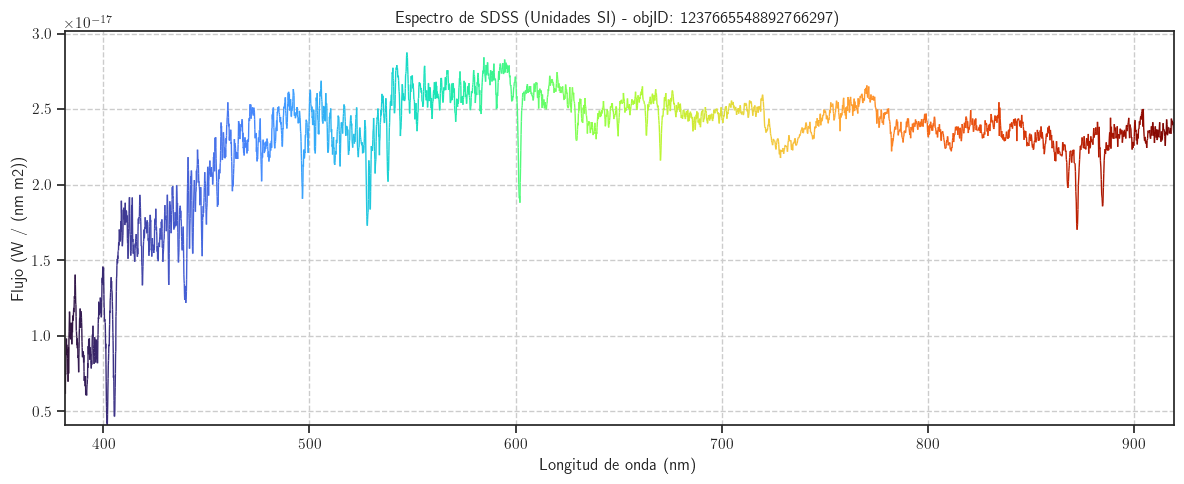

In [7]:
from services.sdss import parse_to_si
from services.plotting import plot_physical_spectrum

wavelength = sdss_spectra_data["loglam"]
flux = sdss_spectra_data["flux"]

sdss_spectrum_si = parse_to_si(wavelength, flux)

plot_physical_spectrum(
    spectrum=sdss_spectrum_si,
    title=f"Espectro de SDSS (Unidades SI) - objID: {sdss_sample_object['bestObjID']})",
)



 #### Gaia - Flujo y Longitud de Onda para una objeto

In [9]:
import services.plotting as spl
from specutils import Spectrum
import astropy.units as u

spl.plot_physical_spectrum(
    spectrum=gaia_object_spectrum, title="Espectro de Gaia para un objeto"
)

# # %% [markdown]
# # #### Gaia - Flujo y Longitud de Onda para múltiples objetos

# # %%
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# df = pd.concat(
#     [
#         v[0].to_table().to_pandas().assign(source=key.split()[-1].replace(".xml", ""))
#         for key, v in gaia_spectra_data.items()
#     ],
#     ignore_index=True,
# )

# sns.lineplot(data=df, x="wavelength", y="flux", hue="source")
# plt.show()


NameError: name 'gaia_object_spectrum' is not defined

Extraer los datos de Gaia en diversas llamadas

In [ ]:
from pathlib import Path
from astroquery.gaia import Gaia
from astropy.table import Table, vstack
import time

gaia_query_path = Path("services", "queries", "gaia_sdss_random_subset.adql")
gaia_query_template = gaia_query_path.read_text(encoding="utf-8")

# Configuración de rangos, modificar para diferentes inicios
start = 0
end = 100000
step = 10000

random_ranges = [
    (i, i + step)
    for i in range(start, end, step)
]

gaia_results_list = []

for start_index, end_index in random_ranges:
    print(f"Ejecutando query para rango de random_index {start_index} - {end_index}...")

    gaia_query = gaia_query_template.format(start_index=start_index, end_index=end_index)

    try:
        gaia_query_job = Gaia.launch_job_async(gaia_query)
        result = gaia_query_job.get_results()

        if result is not None and len(result) > 0:
            print(f" Objetos obtenidos en el intervalo: {len(result)}")
            gaia_results_list.append(result)
        else:
            print(" No se obtuvieron resultados en este rango.")

    except Exception as e:
        print(f" Error en el rango {start_index}-{end_index}: {e}")

    time.sleep(1)

if len(gaia_results_list) > 0:
    gaia_job_results = vstack(gaia_results_list)
else:
    gaia_job_results = Table()

print(f"\nTotal de objetos Gaia recolectados: {len(gaia_job_results)}")

display(gaia_job_results)

Ejecutando query para rango de random_index 0 - 10000...
INFO: Query finished. [astroquery.utils.tap.core]
 Objetos obtenidos en el intervalo: 131
Ejecutando query para rango de random_index 10000 - 20000...
INFO: Query finished. [astroquery.utils.tap.core]
 Objetos obtenidos en el intervalo: 141
Ejecutando query para rango de random_index 20000 - 30000...
INFO: Query finished. [astroquery.utils.tap.core]
 Objetos obtenidos en el intervalo: 160
Ejecutando query para rango de random_index 30000 - 40000...
INFO: Query finished. [astroquery.utils.tap.core]
 Objetos obtenidos en el intervalo: 136
Ejecutando query para rango de random_index 40000 - 50000...
INFO: Query finished. [astroquery.utils.tap.core]
 Objetos obtenidos en el intervalo: 123
Ejecutando query para rango de random_index 50000 - 60000...
INFO: Query finished. [astroquery.utils.tap.core]
 Objetos obtenidos en el intervalo: 132
Ejecutando query para rango de random_index 60000 - 70000...
INFO: Query finished. [astroquery.uti

source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
284595807324018944,77.01471410515663,60.11782791540674,18.248955,16.47685,1237667206744507270,0.03732705
3033376732198466432,113.55278552146389,-13.228812451430889,15.485461,14.208205,1237676676615898394,0.034185585
1154406914752006144,222.59007607238283,2.3425861832919885,17.853062,16.53074,1237651736849350806,0.038843654
4299240895847854208,300.95065510348076,9.36235866814672,17.626791,16.579626,1237666210333197987,0.02349157
286684600242041088,87.93928734400812,62.81940357123728,16.359398,15.297744,1237667206210191919,0.0053555067
545845370721163264,40.35141976475039,72.60547698121222,12.949248,11.929797,1237671071143362774,0.040905617
1031890945409209984,125.98987168753544,53.007689046143376,17.271585,15.714687,1237663546365706415,0.03616886
1974376404191490176,327.20932489621964,45.99797670957075,15.2738905,14.362784,1237671938748776886,0.0057552187


In [ ]:
# Función para dividir la lista en bloques de 250 (para que SDSS nos deje acceder)
def separate_list(values, batch_size=250):
    for i in range(0, len(values), batch_size):
        yield values[i:i + batch_size]

In [ ]:
import numpy as np

sdss_crossmatch_ids = gaia_job_results["original_ext_source_id"]

# Convertimos a enteros/strings y eliminamos valores nulos si los hubiera
sdss_crossmatch_ids = [
    str(x)
    for x in sdss_crossmatch_ids
    if x is not None and str(x) != "" and str(x).lower() != "nan"
]

print(f"Total de IDs SDSS a consultar: {len(sdss_crossmatch_ids)}")

Total de IDs SDSS a consultar: 1377


In [ ]:
from astroquery.sdss import SDSS
import services.querying as sq
import time

sdss_query_path = Path("services", "queries", "sdss.adql")
sdss_query_template = sdss_query_path.read_text(encoding="utf-8")
sdss_query_template_sanitized = sq.sanitize_adql(sdss_query_template)

batch_size = 250

sdss_results_list = []

id_batch = list(separate_list(sdss_crossmatch_ids, batch_size=batch_size))

print(f"Número de batches SDSS a consultar: {len(id_batch)}")

for batch_number, ids_batch in enumerate(id_batch, start=1):
    print(
        f"Consultando batch {batch_number}/{len(id_batch)} "
        f"con {len(ids_batch)} IDs..."
    )

    query_filter_ids = ",".join(ids_batch)

    sdss_query = sdss_query_template_sanitized.format(
        filter_ids=query_filter_ids
    )

    try:
        result = SDSS.query_sql(
            sdss_query,
            data_release=13
        )

        if result is not None and len(result) > 0:
            print(f" Objetos SDSS encontrados: {len(result)}")
            sdss_results_list.append(result)
        else:
            print(" No se encontraron objetos SDSS en este bloque.")

    except Exception as e:
        print(f" Error en bloque {batch_number}: {e}")

    # Pausa para no saturar el servicio
    time.sleep(1)


if len(sdss_results_list) > 0:
    sdss_query_result = vstack(sdss_results_list)
else:
    sdss_query_result = Table()

print(f"\nTotal de objetos SDSS encontrados: {len(sdss_query_result)}")

display(sdss_query_result)

Número de batches SDSS a consultar: 6
Consultando batch 1/6 con 250 IDs...
 Objetos SDSS encontrados: 2
Consultando batch 2/6 con 250 IDs...
 Objetos SDSS encontrados: 4
Consultando batch 3/6 con 250 IDs...
 Objetos SDSS encontrados: 3
Consultando batch 4/6 con 250 IDs...
 Objetos SDSS encontrados: 3
Consultando batch 5/6 con 250 IDs...
 Objetos SDSS encontrados: 5
Consultando batch 6/6 con 127 IDs...
 Objetos SDSS encontrados: 1

Total de objetos SDSS encontrados: 18


bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237665548892766297,2413980315933501440,2144,53770,185,0.02115821
1237678617406210404,3542239791556960256,3146,54773,577,-0.000279155
1237659149387563016,3712144852314595328,3297,54941,192,-0.000235833
1237662300827877635,1887059698834761728,1676,53147,187,1.22274
1237666209782563492,2459015758491969536,2184,53534,183,-0.0002618367
1237671142546342036,3028764553421809664,2690,54211,341,0.0003355562
1237656495653847070,3600701101227220992,3198,54865,266,-0.0005022312
1237658630769082409,1818439178464028672,1615,53166,403,0.0004315955
1237678617434718210,4216670061287313408,3745,55234,636,2.520728


In [ ]:
from astropy.table import join, Table

# Guardamos referencias comunes de ambos satélites
gaia_sdss_common = join(
    gaia_job_results,
    sdss_query_result,
    keys_left="original_ext_source_id",
    keys_right="bestObjID",
    join_type="inner"
)

print(f"Objetos comunes Gaia-SDSS: {len(gaia_sdss_common)}")

display(gaia_sdss_common)

Objetos comunes Gaia-SDSS: 18


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance,bestObjID,specObjID,plate,mjd,fiberID,redshift
,deg,deg,mag,mag,,arcsec,,,,,,
int64,float64,float64,float32,float32,int64,float32,int64,uint64,int64,int64,int64,float64
857539664310198272,169.80555827533604,58.68186191158194,17.919144,17.06511,1237655107837689867,0.09361063,1237655107837689867,2695447059409954816,2394,54551,155,-0.0002362201
1308974472679778304,257.45075277225425,29.57907119791902,17.45626,15.876958,1237655472900211268,0.02533424,1237655472900211268,5626168110249545728,4997,55738,168,-8.493909e-05
2780126940517565824,7.795212008276678,15.025624611570457,17.151657,16.16204,1237656495653847070,0.08788732,1237656495653847070,3600701101227220992,3198,54865,266,-0.0005022312
3907992224394950528,187.14389337206893,13.069695640238544,16.89181,16.234444,1237658630769082409,0.009881143,1237658630769082409,1818439178464028672,1615,53166,403,0.0004315955
1589762907457297280,228.47946990984158,50.97969443927994,16.189617,15.30423,1237659149387563016,0.067105286,1237659149387563016,3712144852314595328,3297,54941,192,-0.000235833
3740380472833279616,206.04014034592456,12.687205318815103,16.76297,16.080265,1237661818176667652,0.033878293,1237661818176667652,1915244579817285632,1701,53142,323,0.000117557
1585715325981468928,224.83771784388213,43.95493339834955,18.701752,18.239342,1237662300827877635,0.043313846,1237662300827877635,1887059698834761728,1676,53147,187,1.22274
1181566776103324672,223.21981644832076,12.501513154207483,16.828114,14.305894,1237662530606858510,0.02884606,1237662530606858510,3837186262545047552,3408,54948,434,-0.0001137369


Dejo las siguientes dos casillas para hacer login y logout porque me va fallando de vez en cuando

In [ ]:
# Login en Gaia por si mejora la conexión
Gaia.login(
    user="csequero",
    password="Master_26"
)


INFO: Login to gaia TAP server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


In [ ]:
Gaia.logout()

INFO: Gaia TAP server logout OK [astroquery.gaia.core]
INFO: Gaia data server logout OK [astroquery.gaia.core]


In [ ]:
xp_data = {}
xp_log = []

source_ids = [
    str(x)
    for x in gaia_sdss_common["source_id"]
]
source_id_batch = list(separate_list(source_ids, batch_size=batch_size))

print(f"Número de batches a consultar: {len(source_id_batch)}")

for batch_number, ids_batch in enumerate(source_id_batch, start=1):
    print(
        f"Consultando bloque {batch_number}/{len(source_id_batch)} "
        f"con {len(ids_batch)} objetos..."
    )

    ids_text = ",".join(ids_batch)

    try:
        gaia_spectra_data = Gaia.load_data(
            ids=ids_text,
            data_release="Gaia DR3",
            retrieval_type="XP_CONTINUOUS",
            data_structure="INDIVIDUAL",
            format="votable",
            dump_to_file=False,
        )

        print(f" Productos recibidos: {len(gaia_spectra_data)}")

        for key, product_list in gaia_spectra_data.items():
            try:
                table = product_list[0].to_table()

                # XP_CONTINUOUS devuelve una fila por fuente
                row = table[0]
                source_id = str(row["source_id"])

                # Extraer coeficientes
                bp_coefficients = list(row["bp_coefficients"])
                rp_coefficients = list(row["rp_coefficients"])

                # Guardamos datos en diccionario
                xp_data[source_id] = {
                    "source_id": source_id,
                    "bp_coefficients": bp_coefficients,
                    "rp_coefficients": rp_coefficients,
                }

            except Exception as e:
                xp_log.append({
                    "source_id": str(key),
                    "status": "error_product",
                    "message": str(e),
                })

                print(f" Error procesando objeto {key}: {e}")

    except Exception as e:
        print(f" Error en bloque {batch_number}: {e}")

        for id_s in ids_batch:
            xp_log.append({
                "source_id": id_s,
                "status": "error_block",
                "message": str(e),
            })

    time.sleep(2)

print(f"\nTotal objetos con coeficientes XP extraídos: {len(xp_data)}")

Número de batches a consultar: 1
Consultando bloque 1/1 con 18 objetos...
 Productos recibidos: 18

Total objetos con coeficientes XP extraídos: 18


In [ ]:
sdss_data = {}

for i, row in enumerate(gaia_sdss_common, start=1):
    source_id = str(row["source_id"])
    bestObjID = str(row["bestObjID"])

    plate = int(row["plate"])
    mjd = int(row["mjd"])
    fiberID = int(row["fiberID"])

    try:
        sdss_spectra_response = (
            SDSS.get_spectra(
                plate=plate,
                mjd=mjd,
                fiberID=fiberID,
                data_release=13,
            )
            or []
        )

        if len(sdss_spectra_response) == 0:
            continue

        sdss_fits_file = sdss_spectra_response[0]
        sdss_spectra_hdu = sdss_fits_file[1]
        sdss_spectra_data = sdss_spectra_hdu.data

        wavelength = sdss_spectra_data["loglam"]
        flux = sdss_spectra_data["flux"]

        sdss_spectrum_si = parse_to_si(wavelength, flux)

        sdss_data[source_id] = {
            "source_id": source_id,
            "bestObjID": bestObjID,
            "plate": plate,
            "mjd": mjd,
            "fiberID": fiberID,
            "sdss_spectra_data": sdss_spectra_data,
            "wavelength": wavelength,
            "flux": flux,
            "sdss_spectrum_si": sdss_spectrum_si,
        }

    except Exception as e:
        print(f"  Error: {e}")

    time.sleep(1)

print(f"Total espectros SDSS guardados: {len(sdss_data)}")

Total espectros SDSS guardados: 18


Ahora guardamos los datos en npy

In [ ]:
import numpy as np

processed_dir = Path("data")

In [ ]:
X_entry = []
dataset_source_ids = []

for source_id in source_ids:
    gaia_obj = xp_data[source_id]

    bp_coefficients = np.array(
        gaia_obj["bp_coefficients"],
        dtype=np.float32
    )

    rp_coefficients = np.array(
        gaia_obj["rp_coefficients"],
        dtype=np.float32
    )

    x = np.concatenate([
        bp_coefficients,
        rp_coefficients
    ])

    X_entry.append(x)
    dataset_source_ids.append(source_id)

X_entry = np.array(X_entry, dtype=np.float32)

print("Shape X:", X_entry.shape)

np.save(
    processed_dir / "X_gaia_xp_coefficients.npy",
    X_entry
)

Shape X: (18, 110)


In [ ]:
# Son longitudes diferentes, primero deberiamos hacer lo de quedarnos con menos datos por cada espectro
lengths = []

for source_id in source_ids:
    flux = sdss_data[source_id]["flux"]
    lengths.append(len(flux))

print("Longitudes únicas:", sorted(set(lengths)))

Longitudes únicas: [3813, 3820, 3825, 3829, 3830, 3831, 3832, 3835, 3838, 3839, 3841, 3842, 3843, 3847, 4626, 4627]


In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

ISPEC_PATH = "/Users/carlasequero/iSpec"

if ISPEC_PATH not in sys.path:
    sys.path.insert(0, ISPEC_PATH)

import ispec

atomic_linelist_file = "/Users/carlasequero/iSpec/input/linelists/transitions/VALD.300_1100nm/atomic_lines.tsv"
solar_abundances_file = "/Users/carlasequero/iSpec/input/abundances/Grevesse.2007/stdatom.dat"
isotope_file = "/Users/carlasequero/iSpec/input/isotopes/SPECTRUM.lst"
model_atmospheres_dir = "/Users/carlasequero/iSpec/input/atmospheres/MARCS.GES/"

print("SPECTRUM activo:", ispec.is_spectrum_support_enabled())

wave_base = 500.0
wave_top = 510.0

atomic_linelist = ispec.read_atomic_linelist(
    atomic_linelist_file,
    wave_base=wave_base,
    wave_top=wave_top
)

isotopes = ispec.read_isotope_data(isotope_file)
solar_abundances = ispec.read_solar_abundances(solar_abundances_file)
modeled_layers_pack = ispec.load_modeled_layers_pack(model_atmospheres_dir)

print("Número de líneas cargadas:", len(atomic_linelist))
print("Recursos cargados")

SPECTRUM activo: True
Número de líneas cargadas: 19644
Recursos cargados


In [3]:
teff = 5777
logg = 4.44
mh = 0.0
alpha = 0.0

microturbulence = 1.0
macroturbulence = 2.0
vsini = 2.0
limb_darkening_coeff = 0.6

target = {
    "teff": teff,
    "logg": logg,
    "MH": mh,
    "alpha": alpha
}

print("Target válido:", ispec.valid_atmosphere_target(modeled_layers_pack, target))

atmosphere_layers = ispec.interpolate_atmosphere_layers(
    modeled_layers_pack,
    target,
    code="spectrum"
)

print("Atmósfera interpolada")

Target válido: True
Atmósfera interpolada


In [4]:
wave = np.arange(wave_base, wave_top, 0.002)

synth_flux = ispec.generate_spectrum(
    wave,
    atmosphere_layers,
    teff,
    logg,
    mh,
    alpha,
    atomic_linelist,
    isotopes,
    solar_abundances,
    fixed_abundances=None,
    microturbulence_vel=microturbulence,
    macroturbulence=macroturbulence,
    vsini=vsini,
    limb_darkening_coeff=limb_darkening_coeff,
    R=100000,
    regions=None,
    verbose=1,
    code="spectrum"
)

print("Tipo:", type(synth_flux))
print("Shape:", np.shape(synth_flux))
print("Min:", np.nanmin(synth_flux))
print("Max:", np.nanmax(synth_flux))
print("Median:", np.nanmedian(synth_flux))
print("Ceros:", np.sum(synth_flux == 0))

[2026-05-28 20:44:47,102] [INFO] [utils:_init_num_threads:160]: NumExpr defaulting to 8 threads.
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (



SPECTRUM, a Stellar Spectral Synthesis Program
(C) Richard O. Gray 1992 - 2010 Version 2.76e
May 3, 2010
* Linked to Python by Sergi Blanco Cuaresma - February 2012

Integrated Disk mode (normalized Intensity)

Isotopes enabled
Teff =   5777 log(g) =  4.44 [M/H] =  0.00

Calculating Partition Functions for all species for all levels
Completed level 0  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  
Calculating Number Densities
Completed Level:  0  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55 

Calculating Ionization ratios for all atoms at all levels
Completed atomic number:  3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  

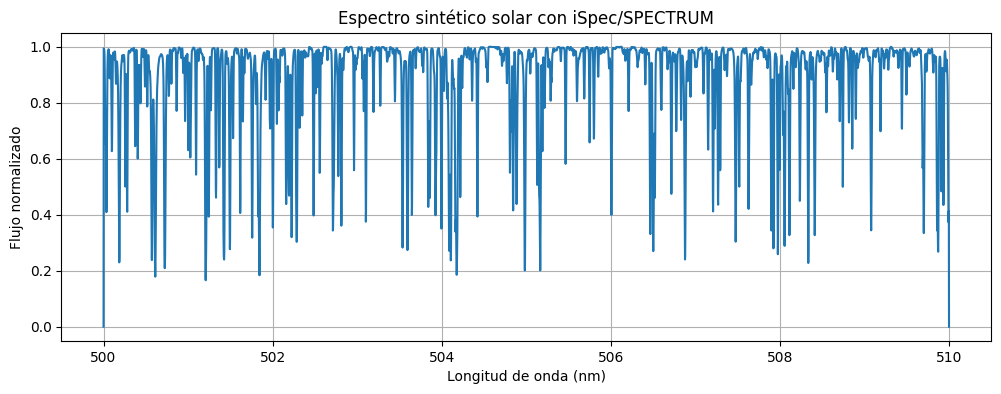

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(wave, synth_flux)
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Flujo normalizado")
plt.title("Espectro sintético solar con iSpec/SPECTRUM")
plt.grid(True)
plt.show()

In [6]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

def degrade_resolution_constant_R(wave_nm, flux, r_from, r_to):
    """
    Degrada un espectro desde resolución r_from hasta r_to
    usando una convolución gaussiana aproximada.
    """
    wave_nm = np.asarray(wave_nm)
    flux = np.asarray(flux)

    if r_to >= r_from:
        return flux.copy()

    delta_lambda = np.median(np.diff(wave_nm))
    lambda_central = np.nanmedian(wave_nm)

    fwhm_from = lambda_central / r_from
    fwhm_to = lambda_central / r_to

    fwhm_kernel = np.sqrt(max(fwhm_to**2 - fwhm_from**2, 0.0))
    sigma_kernel_nm = fwhm_kernel / 2.355
    sigma_kernel_pix = sigma_kernel_nm / delta_lambda

    degraded_flux = gaussian_filter1d(
        flux,
        sigma_kernel_pix,
        mode="nearest"
    )

    return degraded_flux


def resample_spectrum(wave_in, flux_in, wave_out):
    """
    Interpola el espectro a una nueva malla de longitudes de onda.
    """
    interpolator = interp1d(
        wave_in,
        flux_in,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan
    )

    return interpolator(wave_out)

In [7]:
# Resoluciones
R_HIGH = 100000
R_SDSS = 2000

# Malla tipo SDSS para este rango pequeño
# Paso de 0.1 nm para reducir bastante el número de puntos
sdss_wave = np.arange(500.0, 510.0, 0.1)

# Degradar resolución
sdss_flux_high_grid = degrade_resolution_constant_R(
    wave,
    synth_flux,
    r_from=R_HIGH,
    r_to=R_SDSS
)

# Remuestrear
sdss_flux = resample_spectrum(
    wave,
    sdss_flux_high_grid,
    sdss_wave
)

print("Puntos alta resolución:", len(wave))
print("Puntos SDSS-like:", len(sdss_wave))

print("SDSS-like min:", np.nanmin(sdss_flux))
print("SDSS-like max:", np.nanmax(sdss_flux))
print("SDSS-like median:", np.nanmedian(sdss_flux))

Puntos alta resolución: 5000
Puntos SDSS-like: 100
SDSS-like min: 0.420279118916372
SDSS-like max: 0.9684383304857872
SDSS-like median: 0.890483240203666


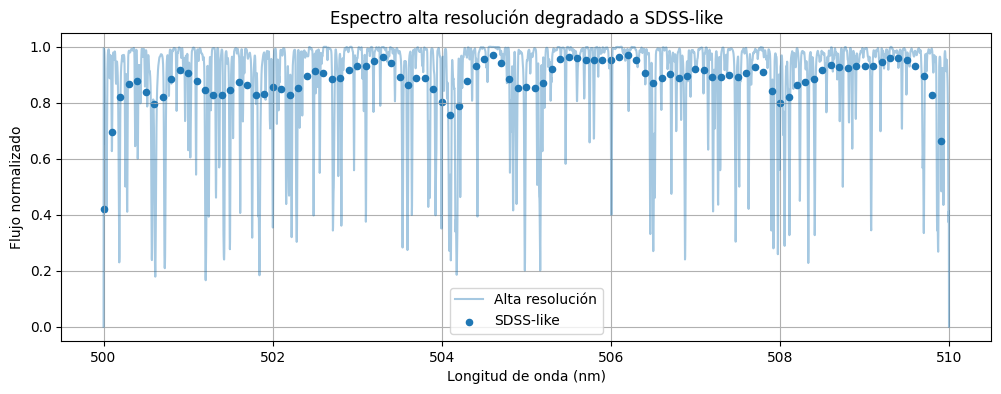

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(wave, synth_flux, alpha=0.4, label="Alta resolución")
plt.scatter(sdss_wave, sdss_flux, s=20, label="SDSS-like")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Flujo normalizado")
plt.title("Espectro alta resolución degradado a SDSS-like")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
R_GAIA = 50

# Malla Gaia-like más gruesa
gaia_wave = np.arange(500.0, 510.0, 1.0)

gaia_flux_high_grid = degrade_resolution_constant_R(
    wave,
    synth_flux,
    r_from=R_HIGH,
    r_to=R_GAIA
)

gaia_flux = resample_spectrum(
    wave,
    gaia_flux_high_grid,
    gaia_wave
)

print("Puntos alta resolución:", len(wave))
print("Puntos SDSS-like:", len(sdss_wave))
print("Puntos Gaia-like:", len(gaia_wave))

print("Gaia-like min:", np.nanmin(gaia_flux))
print("Gaia-like max:", np.nanmax(gaia_flux))
print("Gaia-like median:", np.nanmedian(gaia_flux))

Puntos alta resolución: 5000
Puntos SDSS-like: 100
Puntos Gaia-like: 10
Gaia-like min: 0.43166149129370723
Gaia-like max: 0.6754342991791548
Gaia-like median: 0.6050683587760983


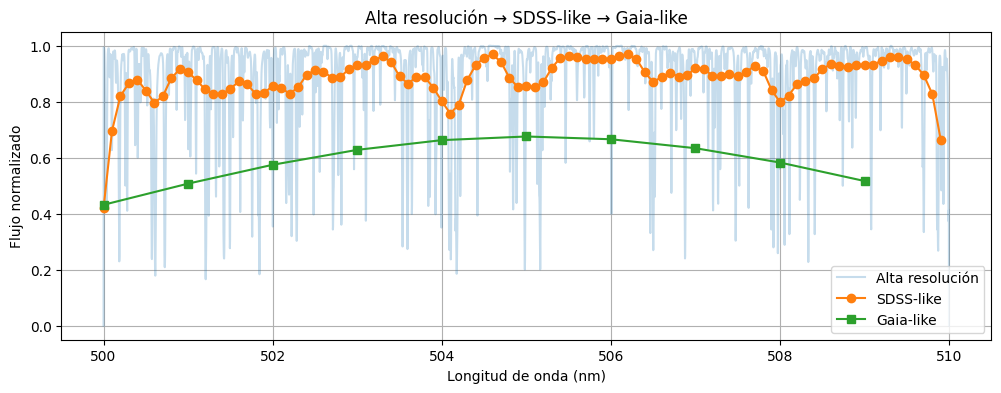

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(wave, synth_flux, alpha=0.25, label="Alta resolución")
plt.plot(sdss_wave, sdss_flux, marker="o", label="SDSS-like")
plt.plot(gaia_wave, gaia_flux, marker="s", label="Gaia-like")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Flujo normalizado")
plt.title("Alta resolución → SDSS-like → Gaia-like")
plt.legend()
plt.grid(True)
plt.show()